In [11]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from dotenv import load_dotenv
load_dotenv()
news_api_key = os.getenv("NEWS_API_KEY")
fred_api_key = os.getenv("FRED_API_KEY")

import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

from newsapi import NewsApiClient

from fredapi import Fred

In [50]:
ticker = "AAPL"
start_date = "2010-01-01"
end_date = "2011-01-01"

df = yf.download(ticker, start=start_date, end=end_date)

df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

df.dropna(inplace=True)
df = df.xs('AAPL', axis=1, level=1)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2010-03-16,6.725195,6.741076,6.667067,6.717106,446908000
2010-03-17,6.715309,6.785122,6.689840,6.738680,450956800
2010-03-18,6.731190,6.741677,6.670065,6.714709,342109600
2010-03-19,6.659278,6.748867,6.628715,6.735384,559445600
2010-03-22,6.734187,6.771641,6.596357,6.605946,456419600


In [ ]:
model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

def get_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    outputs = model(**inputs)
    prediction = torch.nn.functional.softmax(outputs.logits, dim=-1)
    
    probs = prediction.detach().numpy()[0]
    sentiment_score = probs[0] - probs[1]

    return sentiment_score

newsapi = NewsApiClient(api_key=news_api_key)

fred = Fred(api_key=fred_api_key)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 12394.41it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [54]:
sp500 = fred.get_series('SP500')
fed_rate = fred.get_series('FEDFUNDS')

fed_df = fed_rate.to_frame(name='fed_rate')
sp500_df = sp500.to_frame(name='sp500_index')

df = df.merge(fed_df, left_index=True, right_index=True, how='left')
df = df.merge(sp500_df, left_index=True, right_index=True, how='left')

df['fed_rate'] = df['fed_rate'].ffill()
df['sp500_index'] = df['sp500_index'].ffill()

In [32]:
response = newsapi.get_everything(q='Apple', language='en', sort_by='relevancy', from_param=start_date, to=end_date)

news_df = pd.DataFrame(response['articles'])

news_df['date'] = pd.to_datetime(news_df['publishedAt']).dt.date
news_df['sentiment'] = news_df['title'].apply(lambda x: get_sentiment(x))
daily_sentiment = news_df.groupby('date')['sentiment'].mean()

df = df.merge(daily_sentiment, left_index=True, right_index=True, how='left')

df['sentiment'] = df['sentiment'].ffill()
df.dropna(inplace=True)

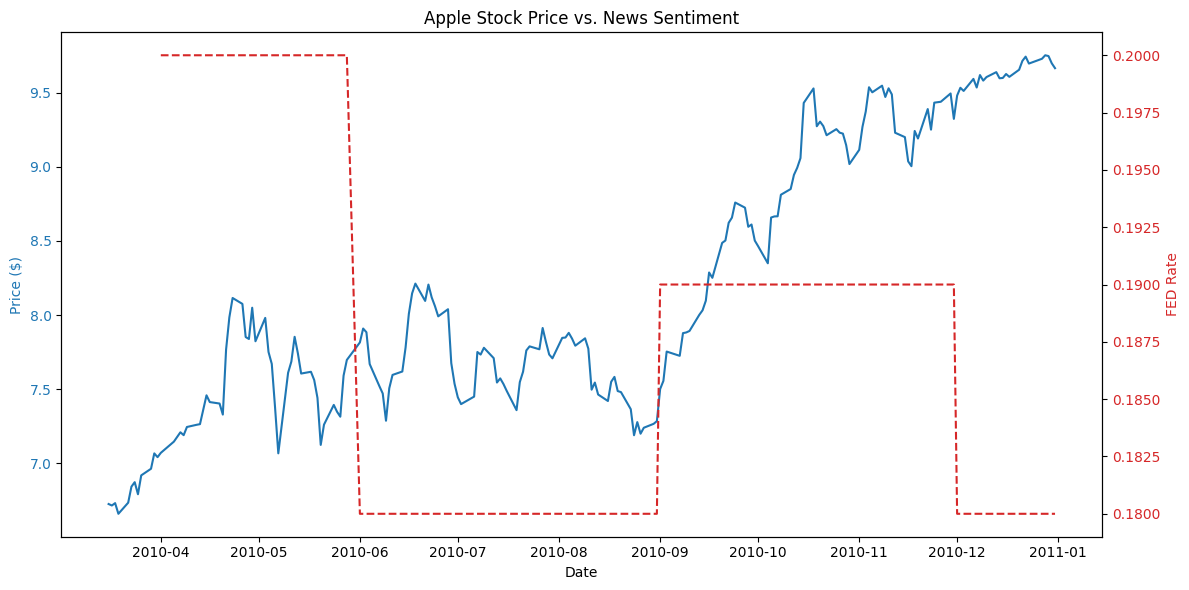

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date')
ax1.set_ylabel('Price ($)', color='tab:blue')
ax1.plot(df.index, df['Close'], color='tab:blue', label='AAPL Price')
ax1.tick_params(axis='y', labelcolor='tab:blue')
#ax2 = ax1.twinx()  
#ax2.set_ylabel('Sentiment Score', color='tab:red')
#ax2.plot(df.index, df['sentiment'], color='tab:red', linestyle='--', label='Sentiment')
#ax2.tick_params(axis='y', labelcolor='tab:red')
plt.title('Apple Stock Price vs. News Sentiment')
fig.tight_layout()
plt.show()